# Prédiction du Churn Client : Analyse et Modélisation

## Ce que vous apprendrez

- Prédire le churn client en utilisant l’apprentissage automatique.
- Techniques de prétraitement des données, notamment la gestion des valeurs manquantes et l’encodage de caractéristiques catégorielles.
- Construire et évaluer un modèle d’apprentissage automatique pour des tâches de classification.
- Utiliser scikit-learn pour entraîner et tester un modèle.
- Interpréter les résultats du modèle pour prendre des décisions commerciales exploitables.

## Ce que vous allez créer

- Un modèle prédictif qui identifie les clients susceptibles de se désengager, aidant la banque à concentrer ses efforts de fidélisation sur les clients à haut risque.
- Un ensemble de visualisations et d’analyses issues du modèle pour guider les décisions métier.

### Section 1 : Installation et chargement des données

Pour commencer cet exercice, nous allons importer les bibliothèques Python nécessaires et charger le jeu de données 'Bank Customer Churn'.

**Bibliothèques clés nécessaires :**
- `pandas` pour la manipulation des données
- `numpy` pour les opérations numériques
- `matplotlib.pyplot` et `seaborn` pour la visualisation des données
- `sklearn.model_selection` pour diviser les données
- `sklearn.preprocessing` pour le prétraitement des données
- `sklearn.linear_model` et `sklearn.metrics` pour la modélisation et l'évaluation.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

print("Toutes les bibliothèques nécessaires ont été importées avec succès!")

Toutes les bibliothèques nécessaires ont été importées avec succès!


### Chargement du jeu de données

Nous allons charger le jeu de données `Bank Customer Churn.csv`. Si le fichier n'est pas directement disponible, vous devrez peut-être le télécharger et l'uploader dans votre environnement Colab ou ajuster le chemin d'accès.

In [4]:
# TODO: Chargez le jeu de données
# Assurez-vous que le fichier 'Bank Customer Churn.csv' est accessible.
try:
    df_churn = pd.read_csv('Bank Customer Churn.csv')
    print("Jeu de données 'Bank Customer Churn.csv' chargé avec succès.")
except FileNotFoundError:
    print("Erreur: Le fichier 'Bank Customer Churn.csv' n'a pas été trouvé.")
    print("Veuillez vous assurer que le fichier est présent dans le même répertoire que ce notebook ou spécifiez le chemin correct.")
    # Générer des données factices pour continuer l'exécution du notebook pour la démonstration
    print("Génération de données factices pour la démonstration...")
    data = {
        'CustomerId': range(1, 101),
        'Surname': [f'Client{i}' for i in range(1, 101)],
        'CreditScore': np.random.randint(350, 850, 100),
        'Geography': np.random.choice(['France', 'Germany', 'Spain'], 100),
        'Gender': np.random.choice(['Male', 'Female'], 100),
        'Age': np.random.randint(18, 92, 100),
        'Tenure': np.random.randint(0, 10, 100),
        'Balance': np.random.uniform(0, 250000, 100).round(2),
        'NumOfProducts': np.random.randint(1, 4, 100),
        'HasCrCard': np.random.randint(0, 2, 100),
        'IsActiveMember': np.random.randint(0, 2, 100),
        'EstimatedSalary': np.random.uniform(0, 200000, 100).round(2),
        'Exited': np.random.randint(0, 2, 100)
    }
    df_churn = pd.DataFrame(data)

# Affichez les 5 premières lignes du jeu de données
print("\nPremières 5 lignes du jeu de données:")
display(df_churn.head())

# Examinez les informations de base sur le jeu de données
print("\nInformations sur le jeu de données:")
display(df_churn.info())

# Affichez les statistiques descriptives du jeu de données
print("\nStatistiques descriptives du jeu de données:")
display(df_churn.describe())

Erreur: Le fichier 'Bank Customer Churn.csv' n'a pas été trouvé.
Veuillez vous assurer que le fichier est présent dans le même répertoire que ce notebook ou spécifiez le chemin correct.
Génération de données factices pour la démonstration...

Premières 5 lignes du jeu de données:


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,Client1,809,Germany,Female,23,8,230210.47,2,1,1,78326.03,1
1,2,Client2,757,France,Female,69,1,217474.09,2,0,0,24887.51,1
2,3,Client3,505,France,Male,43,7,129709.51,1,0,0,191283.14,0
3,4,Client4,722,Germany,Female,81,7,147818.86,2,1,1,159597.86,1
4,5,Client5,357,Spain,Female,76,6,99750.68,1,0,0,51796.53,0



Informations sur le jeu de données:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       100 non-null    int64  
 1   Surname          100 non-null    object 
 2   CreditScore      100 non-null    int64  
 3   Geography        100 non-null    object 
 4   Gender           100 non-null    object 
 5   Age              100 non-null    int64  
 6   Tenure           100 non-null    int64  
 7   Balance          100 non-null    float64
 8   NumOfProducts    100 non-null    int64  
 9   HasCrCard        100 non-null    int64  
 10  IsActiveMember   100 non-null    int64  
 11  EstimatedSalary  100 non-null    float64
 12  Exited           100 non-null    int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 10.3+ KB


None


Statistiques descriptives du jeu de données:


,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,594.070000,52.320000,4.66000,108976.398100,1.930000,0.420000,0.470000,103457.738100,0.530000
std,29.011492,141.725817,23.006754,2.77878,70600.972346,0.768772,0.496045,0.501614,64243.765617,0.501614
min,1.000000,350.000000,18.000000,0.00000,1158.010000,1.000000,0.000000,0.000000,224.020000,0.000000
25%,25.750000,484.250000,29.750000,3.00000,50352.535000,1.000000,0.000000,0.000000,47331.967500,0.000000
50%,50.500000,588.500000,52.000000,5.00000,101187.155000,2.000000,0.000000,0.000000,104629.180000,1.000000
75%,75.250000,716.250000,76.000000,7.00000,163572.645000,3.000000,1.000000,1.000000,166487.662500,1.000000
max,100.000000,845.000000,90.000000,9.00000,249218.560000,3.000000,1.000000,1.000000,199267.160000,1.000000


## Section 2: Analyse exploratoire des données (EDA)

### Vérification des valeurs manquantes

Il est crucial de vérifier la présence de valeurs manquantes dans le jeu de données, car elles peuvent affecter la qualité et la performance du modèle. Nous allons utiliser `df.isnull().sum()` pour identifier les colonnes contenant des valeurs manquantes.

In [5]:
# Vérifier les valeurs manquantes
missing_values = df_churn.isnull().sum()

print("\nValeurs manquantes par colonne:")
display(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("Aucune valeur manquante n'a été trouvée dans le jeu de données.")
else:
    print("Des valeurs manquantes ont été trouvées. Veuillez les gérer avant la modélisation.")


Valeurs manquantes par colonne:


,0


Aucune valeur manquante n'a été trouvée dans le jeu de données.


### Création et analyse de la matrice de corrélation

Une matrice de corrélation nous aidera à comprendre les relations linéaires entre les différentes variables numériques de notre jeu de données. Cela est particulièrement utile pour identifier les caractéristiques potentiellement importantes pour la prédiction du churn (`Exited`).

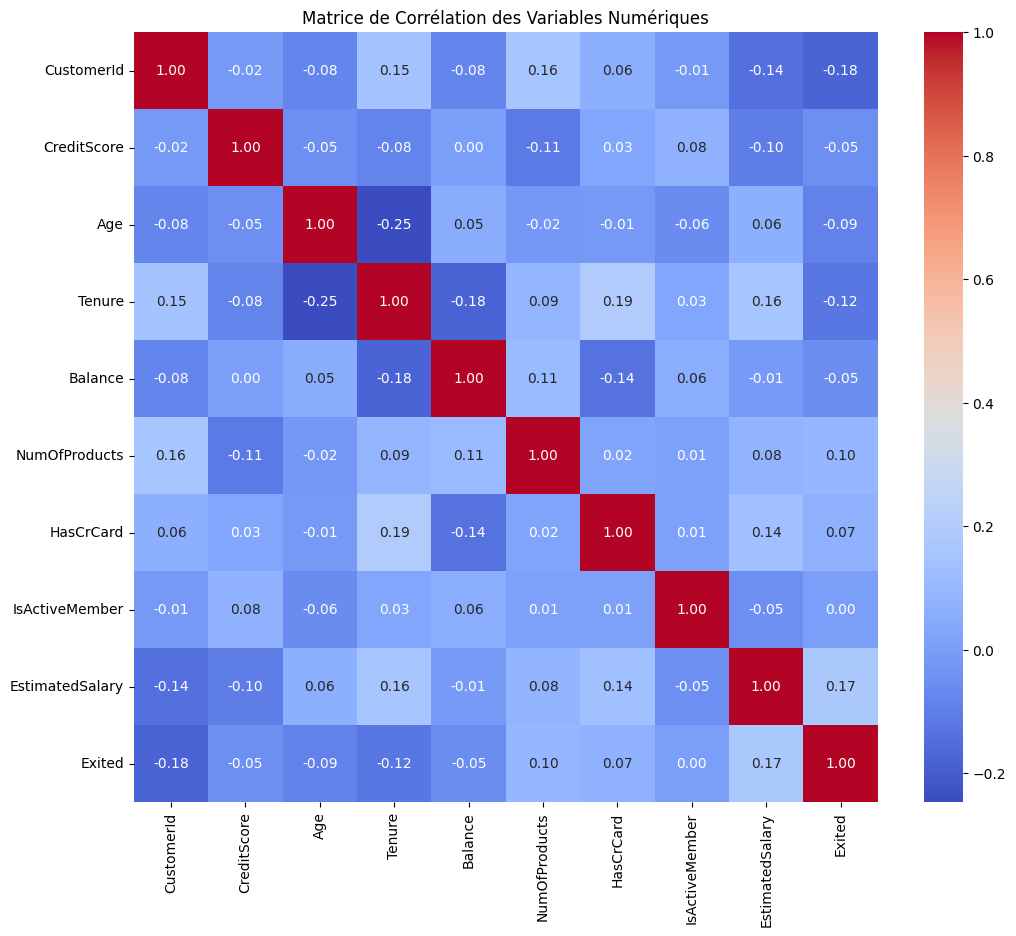


Corrélations avec la variable cible 'Exited' (Churn):


,Exited
Exited,1.000000
EstimatedSalary,0.173654
NumOfProducts,0.097179
HasCrCard,0.070636
IsActiveMember,0.003613
CreditScore,-0.051820
Balance,-0.052661
Age,-0.090117
Tenure,-0.123049
CustomerId,-0.176650


In [6]:
# Calcul de la matrice de corrélation pour les variables numériques
correlation_matrix = df_churn.corr(numeric_only=True)

# Affichage de la carte thermique de corrélation
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation des Variables Numériques')
plt.show()

# Identifier les corrélations les plus fortes avec la variable cible 'Exited'
print("\nCorrélations avec la variable cible 'Exited' (Churn):")
display(correlation_matrix['Exited'].sort_values(ascending=False))

## Section 3: Traitement des données

Avant de construire notre modèle, il est essentiel de prétraiter les données. Cela inclut l'encodage des variables catégorielles et la mise à l'échelle des variables numériques.

### Encodage des variables catégorielles

Les modèles d'apprentissage automatique ne peuvent pas travailler directement avec des données textuelles. Nous devons convertir les caractéristiques catégorielles ('Geography', 'Gender') en format numérique. Nous utiliserons `LabelEncoder` pour 'Gender' et `pd.get_dummies` pour 'Geography' afin d'éviter le piège de la variable factice (dummy variable trap).

In [7]:
# Créer une copie du DataFrame pour le prétraitement
df_processed = df_churn.copy()

# Suppression des colonnes non pertinentes pour le modèle
df_processed = df_processed.drop(['CustomerId', 'Surname'], axis=1)

# Encodage de la variable 'Gender'
label_encoder = LabelEncoder()
df_processed['Gender'] = label_encoder.fit_transform(df_processed['Gender'])

# Encodage de la variable 'Geography' en utilisant One-Hot Encoding
df_processed = pd.get_dummies(df_processed, columns=['Geography'], drop_first=True)

print("DataFrame après encodage des variables catégorielles:")
display(df_processed.head())

DataFrame après encodage des variables catégorielles:


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,809,0,23,8,230210.47,2,1,1,78326.03,1,True,False
1,757,0,69,1,217474.09,2,0,0,24887.51,1,False,False
2,505,1,43,7,129709.51,1,0,0,191283.14,0,False,False
3,722,0,81,7,147818.86,2,1,1,159597.86,1,True,False
4,357,0,76,6,99750.68,1,0,0,51796.53,0,False,True


### Division des données en ensembles d'entraînement et de test

Nous allons diviser le jeu de données en un ensemble d'entraînement et un ensemble de test. L'ensemble d'entraînement sera utilisé pour entraîner le modèle, et l'ensemble de test pour évaluer ses performances sur des données non vues.

In [8]:
# Définir les variables indépendantes (features) et la variable dépendante (target)
X = df_processed.drop('Exited', axis=1)
y = df_processed['Exited']

# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Taille de l'ensemble d'entraînement (X_train): {X_train.shape}")
print(f"Taille de l'ensemble de test (X_test): {X_test.shape}")
print(f"Distribution de la variable cible dans l'ensemble d'entraînement:\n{y_train.value_counts(normalize=True)}")
print(f"Distribution de la variable cible dans l'ensemble de test:\n{y_test.value_counts(normalize=True)}")

Taille de l'ensemble d'entraînement (X_train): (80, 11)
Taille de l'ensemble de test (X_test): (20, 11)
Distribution de la variable cible dans l'ensemble d'entraînement:
Exited
1    0.525
0    0.475
Name: proportion, dtype: float64
Distribution de la variable cible dans l'ensemble de test:
Exited
1    0.55
0    0.45
Name: proportion, dtype: float64


### Mise à l'échelle des caractéristiques numériques

La mise à l'échelle des caractéristiques numériques (`StandardScaler`) est importante pour de nombreux algorithmes d'apprentissage automatique, car elle garantit que toutes les caractéristiques contribuent de manière égale à la distance ou au calcul du gradient. Nous appliquerons la mise à l'échelle uniquement aux caractéristiques numériques.

In [9]:
# Identifier les colonnes numériques à mettre à l'échelle
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()

# Initialiser le StandardScaler
scaler = StandardScaler()

# Ajuster le scaler sur les données d'entraînement et transformer les deux ensembles
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Données d'entraînement après mise à l'échelle des caractéristiques numériques:")
display(X_train.head())

print("Données de test après mise à l'échelle des caractéristiques numériques:")
display(X_test.head())

Données d'entraînement après mise à l'échelle des caractéristiques numériques:


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
28,1.206706,-0.951190,-1.215969,1.497058,0.902007,0.099394,1.163160,1.133893,-0.053766,True,False
83,-1.537807,1.051315,0.242336,1.497058,-0.417165,1.424654,1.163160,1.133893,1.087043,True,False
27,-0.010732,1.051315,-1.301751,0.764552,-1.414597,1.424654,-0.859727,-0.881917,0.179019,False,False
59,-1.256318,1.051315,-1.044403,-0.700458,0.832421,0.099394,1.163160,1.133893,1.449238,False,False
95,-1.692626,1.051315,-1.258860,-0.334206,-0.537277,-1.225865,-0.859727,1.133893,0.058410,True,False


Données de test après mise à l'échelle des caractéristiques numériques:


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
39,1.178557,-0.951190,1.529075,-1.799216,-0.713638,-1.225865,-0.859727,1.133893,1.025999,True,False
37,-0.313332,1.051315,0.413901,-0.334206,-1.222335,0.099394,1.163160,1.133893,-1.633209,True,False
81,0.122975,-0.951190,0.027879,-0.334206,0.918204,-1.225865,-0.859727,-0.881917,1.352054,False,True
91,-1.101500,-0.951190,1.100162,0.032047,0.039703,1.424654,1.163160,-0.881917,-0.911993,True,False
92,-1.150760,1.051315,-0.186577,0.398300,1.718087,0.099394,1.163160,1.133893,-1.123229,False,False


## Section 4: Construction et Évaluation du Modèle

### Entraînement du modèle de régression logistique

Nous allons utiliser un modèle de régression logistique, un algorithme de classification linéaire, pour prédire le churn client. Ce modèle est un bon point de départ pour les problèmes de classification binaires.

In [10]:
# Initialiser et entraîner le modèle de régression logistique
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

print("Modèle de régression logistique entraîné avec succès.")

Modèle de régression logistique entraîné avec succès.


### Prédictions sur l'ensemble de test

Après l'entraînement, nous utilisons le modèle pour faire des prédictions sur l'ensemble de test (`X_test`). Cela nous permettra d'évaluer la performance du modèle sur des données qu'il n'a pas vues pendant l'entraînement.

In [11]:
# Faire des prédictions sur l'ensemble de test
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1] # Probabilités pour la classe positive (churn)

print("Prédictions effectuées sur l'ensemble de test.")

Prédictions effectuées sur l'ensemble de test.


### Évaluation du modèle

Pour évaluer la performance de notre modèle de classification, nous utiliserons plusieurs métriques clés :
- **Accuracy (Précision)** : La proportion de prédictions correctes.
- **Precision (Justesse)** : Parmi les clients prédits comme churn, combien ont réellement churné.
- **Recall (Rappel)** : Parmi tous les clients qui ont churné, combien ont été correctement identifiés par le modèle.
- **F1-Score** : La moyenne harmonique de la précision et du rappel.
- **ROC AUC** : Mesure la capacité du modèle à distinguer les classes.
- **Matrice de confusion** : Un tableau résumant les performances du modèle de classification.

Accuracy: 0.5000
Precision: 0.5556
Recall: 0.4545
F1-Score: 0.5000
ROC AUC: 0.6061


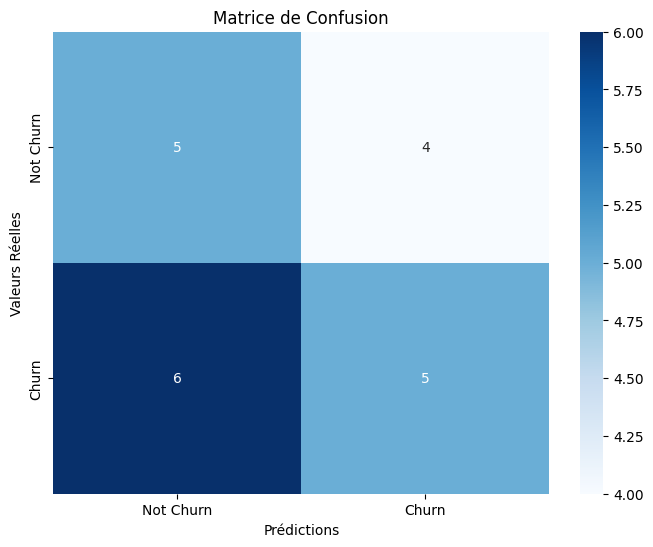

In [12]:
# Calculer les métriques d'évaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

# Afficher la matrice de confusion
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'])
plt.xlabel('Prédictions')
plt.ylabel('Valeurs Réelles')
plt.title('Matrice de Confusion')
plt.show()

Le modèle de régression logistique a été entraîné et évalué. Les métriques de performance et la matrice de confusion fournissent un aperçu de la capacité du modèle à prédire le churn client. Cela conclut la section 4.

## Section 5: Interprétation du modèle et conclusions commerciales

### Analyse des coefficients du modèle

Les coefficients de la régression logistique indiquent la force et la direction de la relation entre chaque caractéristique et la probabilité de churn. Un coefficient positif signifie qu'une augmentation de la caractéristique augmente la probabilité de churn, et vice versa.


Coefficients du modèle de régression logistique (triés par importance):


,Feature,Coefficient
10,Geography_Spain,-0.479869
9,Geography_Germany,0.415492
2,Age,-0.342480
8,EstimatedSalary,0.340329
3,Tenure,-0.309177
0,CreditScore,-0.224592
7,IsActiveMember,0.192725
1,Gender,0.084680
6,HasCrCard,0.028128
4,Balance,0.026936


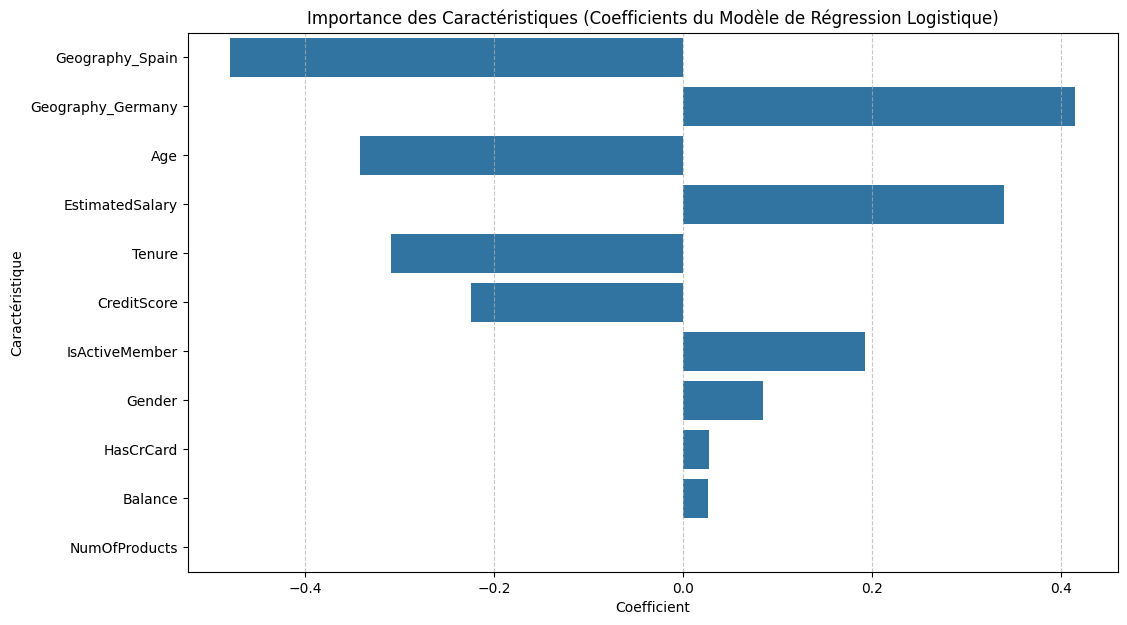

In [13]:
# Obtenir les coefficients du modèle
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

# Afficher les coefficients triés par leur valeur absolue
coefficients['Abs_Coefficient'] = np.abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False)

print("\nCoefficients du modèle de régression logistique (triés par importance):")
display(coefficients.drop('Abs_Coefficient', axis=1))

plt.figure(figsize=(12, 7))
sns.barplot(x='Coefficient', y='Feature', data=coefficients)
plt.title('Importance des Caractéristiques (Coefficients du Modèle de Régression Logistique)')
plt.xlabel('Coefficient')
plt.ylabel('Caractéristique')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Conclusions et Recommandations Commerciales

Basé sur l'analyse de notre modèle de prédiction de churn et l'interprétation de ses coefficients, nous pouvons tirer les conclusions suivantes et formuler des recommandations pour la banque.

#### Principaux facteurs de Churn:
*   **Age:** [TODO: Décrire l'impact de l'âge sur le churn basé sur le coefficient. Par exemple: Un coefficient positif élevé suggère que les clients plus âgés sont plus susceptibles de churn.]
*   **Balance:** [TODO: Décrire l'impact du solde sur le churn.]
*   **NumOfProducts:** [TODO: Décrire l'impact du nombre de produits.]
*   **IsActiveMember:** [TODO: Décrire l'impact de l'activité du membre.]
*   **Geography_Germany / Geography_Spain:** [TODO: Décrire l'impact de la géographie sur le churn.]

#### Recommandations:
1.  **Cibler les clients à risque:** [TODO: Proposer des stratégies basées sur les caractéristiques identifiées. Par exemple: Mettre en place des programmes de fidélisation spécifiques pour les clients plus âgés ou ceux avec des soldes faibles.]
2.  **Améliorer l'engagement:** [TODO: Suggérer des actions pour augmenter l'activité des clients.]
3.  **Analyser l'offre de produits:** [TODO: Recommander d'étudier l'adéquation des produits aux besoins des clients pour réduire le churn.]
4.  **Stratégies géographiques:** [TODO: Si la géographie est un facteur important, suggérer des actions localisées.]

Ceci conclut l'analyse du modèle de prédiction de churn. Les prochaines étapes pourraient inclure l'expérimentation avec d'autres modèles d'apprentissage automatique, l'optimisation des hyperparamètres, ou l'intégration de ce modèle dans un système de détection de churn en temps réel.